In [ ]:
# Ensure the notebook uses the repository root as its working directory whether launched from notebooks/ or the repository root
import os, sys
from pathlib import Path
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))


# Topology Selection

This section uses several machine-learning algorithms to build effective models from ``topology_selec_database-0404.csv``, using circuit name as the label and GBW, `Gain`, and `Pdiss` as features. Given target performance metrics, the models return a predicted topology.

The algorithms considered are:
* Decision tree: For medium-sized datasets (hundreds to thousands of samples), random forests/XGBoost often approach deep-learning performance with lower training difficulty and time cost.
  * Standard decision tree: highly interpretable, but generally less accurate.
  * Random forest: better performance at the cost of some interpretability; requires tuning; 100–200 trees are recommended.
  * XGBoost: similar to random forests.
* SVM: theoretically mature with good generalization, but multiclass problems require multiple models.
* KNN: simple and easy to use, requires no training, and offers moderate performance.
* Neural network: often performs well, but requires substantial data and is difficult to interpret, so it may not be suitable.

## Initialization, Imports, and Data Checks

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# Change the path to the database
Database_path = "circuit_database/result_all_20250522-085704.csv"

In [2]:
# Read data from the CSV
data = pd.read_csv(Database_path)
# Use only the first four columns: circuit name (label) in the first, and the circuit's Pareto-optimal GBW, `Gain`, and `Pdiss` (features) in the next three
#  #   Column        Non-Null Count  Dtype  
# ---  ------        --------------  -----  
#  0   circuit name  857 non-null    object 
#  1   GBW           857 non-null    float64
#  2   Gain          857 non-null    float64
#  3   Pdiss         857 non-null    float64
ml_data = data.iloc[:, :4]
# Strip leading and trailing whitespace from each column name
ml_data.columns = ml_data.columns.str.strip()

# Data statistics and checks
print(ml_data.info())
print("-*-" * 20)
# First five rows
print(ml_data.head())
print("-*-" * 20)
# Group statistics by label
print(ml_data.groupby('circuit name').size())
print("-*-" * 20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   circuit name  634 non-null    object 
 1   GBW           634 non-null    float64
 2   Gain          634 non-null    float64
 3   Pdiss         634 non-null    float64
dtypes: float64(3), object(1)
memory usage: 19.9+ KB
None
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
  circuit name         GBW     Gain     Pdiss
0          SMC  29067700.0  96.6741  0.001395
1          SMC  15400900.0  92.7901  0.000900
2          SMC  25186900.0  97.4497  0.001266
3          SMC  15281100.0  97.6404  0.000970
4          SMC  20791000.0  97.7411  0.000979
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
circuit name
AZC        87
DFCFC1     17
IAC        99
NGCC      104
NMCNR      61
SMC       169
TCFC       97
dtype: int64
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--

In [3]:
# ml_data may contain the same circuit with different load capacitances, reflected in names of the form “{circuit name}_{load}”,

# Merge circuits that share the same circuit-name prefix
ml_data['circuit name'] = ml_data['circuit name'].str.split('_').str[0]
# # or remove circuits with load capacitance
# ml_data = ml_data[~ml_data['circuit name'].str.contains('_')]

# Group statistics by label
print(ml_data.groupby('circuit name').size())
print("-*-" * 20)

circuit name
AZC        87
DFCFC1     17
IAC        99
NGCC      104
NMCNR      61
SMC       169
TCFC       97
dtype: int64
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-


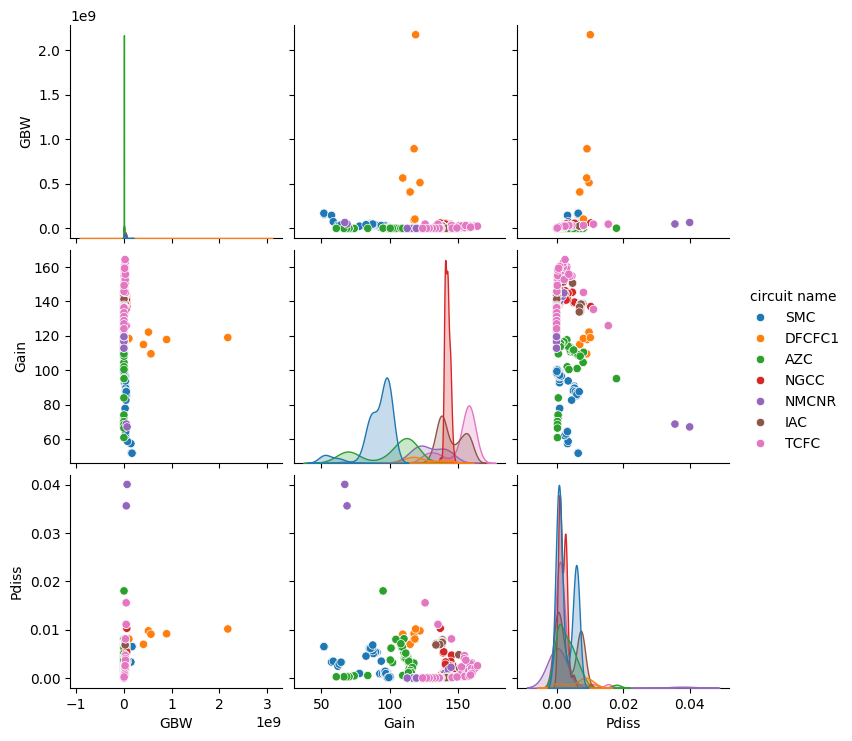

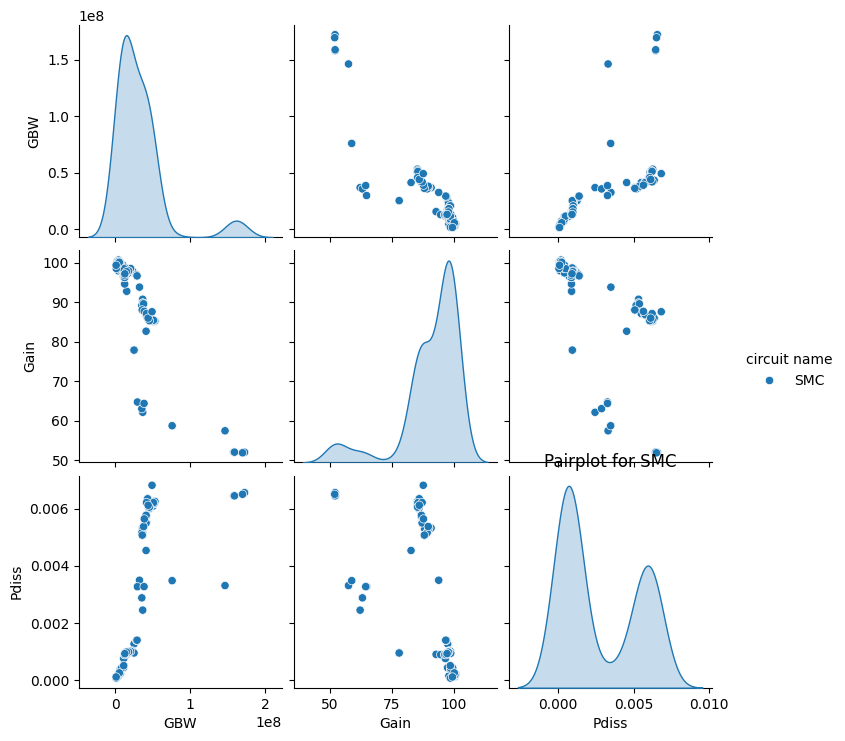

-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
Min and max values for each feature:
GBW min: 165.941, max: 2174260000.0
Gain min: 51.8723, max: 164.261
Pdiss min: 3.06212e-06, max: 0.0400497
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-


In [4]:
# Show the distribution of each feature for every label
sns.pairplot(ml_data, hue='circuit name')

# # Show each label's feature distributions individually
# for label in ml_data['circuit name'].unique():
#     sns.pairplot(ml_data[ml_data['circuit name'] == label], hue='circuit name')
#     plt.title(f"Pairplot for {label}")
#     plt.show()

# Show the feature distributions for one label
label = 'SMC'
ml_data_label = ml_data[ml_data['circuit name'] == label]
sns.pairplot(ml_data_label, hue='circuit name')
plt.title(f"Pairplot for {label}")
plt.show()

# Print the minimum and maximum of each metric
def print_min_max(data):
    for col in data.columns[1:]:
        print(f"{col} min: {data[col].min()}, max: {data[col].max()}")
        
print("-*-" * 20)
print("Min and max values for each feature:")
print_min_max(ml_data)
print("-*-" * 20)

<class 'pandas.core.frame.DataFrame'>
Index: 169 entries, 0 to 168
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   circuit name  169 non-null    object 
 1   GBW           169 non-null    float64
 2   Gain          169 non-null    float64
 3   Pdiss         169 non-null    float64
dtypes: float64(3), object(1)
memory usage: 6.6+ KB
None
  circuit name         GBW     Gain     Pdiss
0          SMC  29067700.0  96.6741  0.001395
1          SMC  15400900.0  92.7901  0.000900
2          SMC  25186900.0  97.4497  0.001266
3          SMC  15281100.0  97.6404  0.000970
4          SMC  20791000.0  97.7411  0.000979
<class 'pandas.core.frame.DataFrame'>
Index: 17 entries, 169 to 185
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   circuit name  17 non-null     object 
 1   GBW           17 non-null     float64
 2   Gain          17 non-null     flo

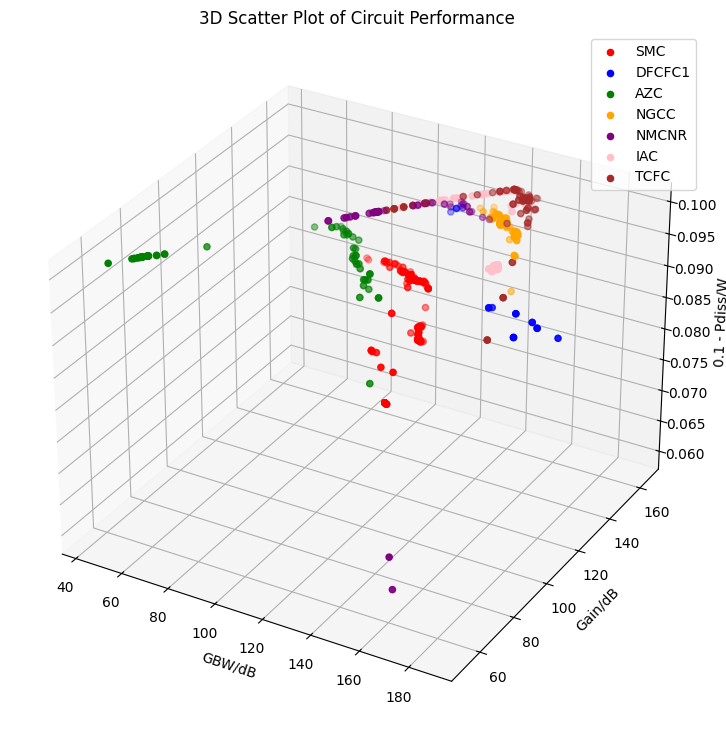

In [5]:
# Use a 3D scatter plot to show each label's performance distribution, with a different color for each label
# Represent `Pdiss` as 0.1-Pdiss to make the Pareto structure clearer
colors = ['red', 'blue', 'green', 'orange', 'purple', 'pink', 'brown', 'gray']
fig = plt.figure(figsize=(9, 9))
# fig = plt.figure(figsize=(10, 10))  # Changes the figure size to a 4:3 aspect ratio

ax = fig.add_subplot(111, projection='3d')

# for i, label in enumerate(["SMC_50pF","SMC","TCFC_50pF","TCFC"]):   # just to check if C_load would affect the performance
for i, label in enumerate(ml_data['circuit name'].unique()):
    ml_data_label = ml_data[ml_data['circuit name'] == label]
    print(ml_data_label.info())
    print(ml_data_label.head())
    ax.scatter(20*np.log10(ml_data_label['GBW']), ml_data_label['Gain'], 0.1 - ml_data_label['Pdiss'], color=colors[i % len(colors)], label=label)

ax.set_xlabel('GBW/dB')
ax.set_ylabel('Gain/dB')
ax.set_zlabel('0.1 - Pdiss/W')
ax.set_title('3D Scatter Plot of Circuit Performance')
ax.legend()
plt.show()

In [6]:
# Reformat the data for machine learning
X = ml_data[['GBW', 'Gain', 'Pdiss']].values
y = ml_data['circuit name']
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
# Quick display
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (634, 3)
y shape: (634,)


## Building the Models

### Cross-Validation and Model Evaluation
* Build a unified evaluation function for all models.
* Use K-fold cross-validation.
* Report Acc, F1, Precision, Recall, and runtime.
* Plot confusion matrices.

In [7]:
# Save the best model after hyperparameter tuning for each model type 
optimal_model_list = []

# Use it to evaluate each model's final performance
def evaluate_model(model, X, y, cv=5, test_size=0.25, random_state=42):
    """
    Evaluate a classification model using cross-validation and various metrics.
    First, a single train-test split is performed, and the model is trained and evaluated on the test set.
    Then, cross-validation is performed to get a more robust estimate of the model's performance.
    Finally, the model is trained on the entire dataset and returned.
    
    Parameters:
    -----------
    model : estimator object
        The model to evaluate
    X : array-like
        Feature data
    y : array-like
        Target labels
    cv : int, default=5
        Number of cross-validation folds
    test_size : float, default=0.25
        Proportion of data to use for testing (not applied in cross-validation)
    random_state : int, default=42
        Random seed for reproducibility
    
    Returns:
    --------
    model : trained model
    """
    
    # 1. Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    print("--" * 10 + " Single Train-Test Split Evaluation " + "--" * 10)
    # Evaluate the model
    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_encoder.classes_, 
                yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    
    
    # 2. Cross-validation
    print("--" * 10 + " Cross-Validation Evaluation " + "--" * 10)
    # Compute multiple metrics
    scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=True)
    # In the returned results, prefix each scoring key with test_ or train_

    # The result contains arrays for multiple metrics
    print(f"Test Accuracy: {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
    print(f"Test F1: {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
    print(f"Test Precision: {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
    print(f"Test Recall: {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
    

    # Training-set metrics can also be obtained
    print(f"Train Accuracy: {cv_results['train_accuracy'].mean():.4f}")

    # as well as timing information
    print(f"Mean Fit Time: {cv_results['fit_time'].mean():.4f}s")
    print(f"Mean Score Time: {cv_results['score_time'].mean():.4f}s")
    
    # 3. The best model should be trained on the entire dataset
    model.fit(X, y)
    
    print("Final Model Trained on Entire Dataset")
    
    return model

### Decision Trees
* Standard CRT tree
* Random forest
* XGBoost

#### Standard CRT Tree
* Hyperparameter tuning: adjust `max_depth` to limit model complexity and prevent overfitting. Start with a shallow tree (for example, depth 3–5), inspect validation accuracy, and increase the depth until there is no clear improvement. You can also set `min_samples_split` or `min_samples_leaf` so each leaf contains enough samples to avoid decisions based on very few observations. Scikit-learn provides `ccp_alpha` for minimal-cost-complexity pruning; use cross-validation to select a pruning coefficient that improves generalization.

-*--*--*--*--*--*--*--*--*--*- CRT Tree Hyperparameter Tuning -*--*--*--*--*--*--*--*--*--*-
Fitting 5 folds for each of 360 candidates, totalling 1800 fits


Best Parameters: {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score: 0.9318710161229846
-*--*--*--*--*--*--*--*--*--*- CRT Tree Best Model Evaluating -*--*--*--*--*--*--*--*--*--*-
-------------------- Single Train-Test Split Evaluation --------------------
Test Accuracy: 0.9245283018867925

Classification Report:
              precision    recall  f1-score   support

         AZC       1.00      0.95      0.98        22
      DFCFC1       1.00      0.50      0.67         4
         IAC       0.92      0.92      0.92        25
        NGCC       0.92      0.85      0.88        26
       NMCNR       0.81      0.87      0.84        15
         SMC       1.00      1.00      1.00        43
        TCFC       0.82      0.96      0.88        24

    accuracy                           0.92       159
   macro avg       0.92      0.86      0.88       159
weighted avg       0.93      0.92      0.92       159



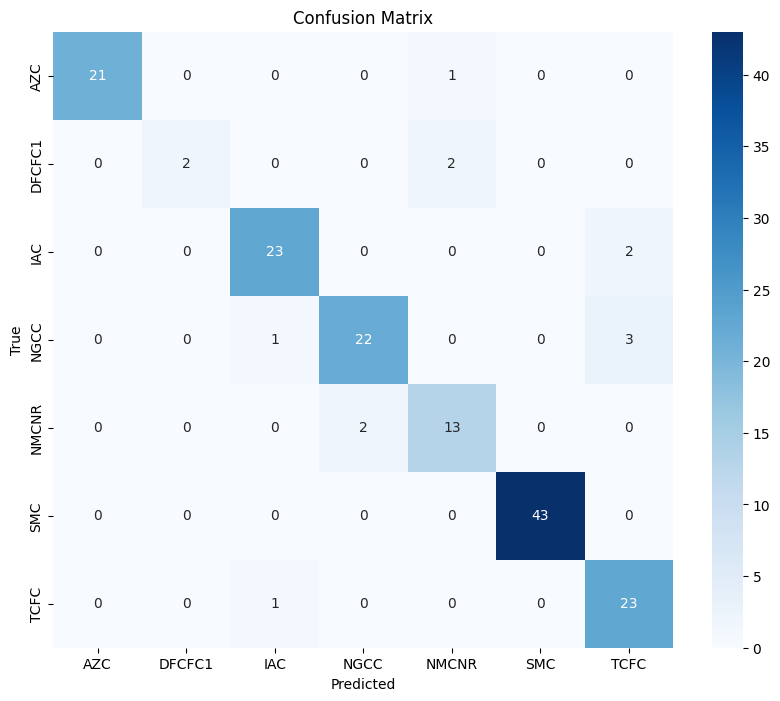

-------------------- Cross-Validation Evaluation --------------------
Test Accuracy: 0.9303 ± 0.1044
Test F1: 0.9242 ± 0.1140
Test Precision: 0.9357 ± 0.0935
Test Recall: 0.9249 ± 0.1135
Train Accuracy: 1.0000
Mean Fit Time: 0.0007s
Mean Score Time: 0.0022s
Final Model Trained on Entire Dataset


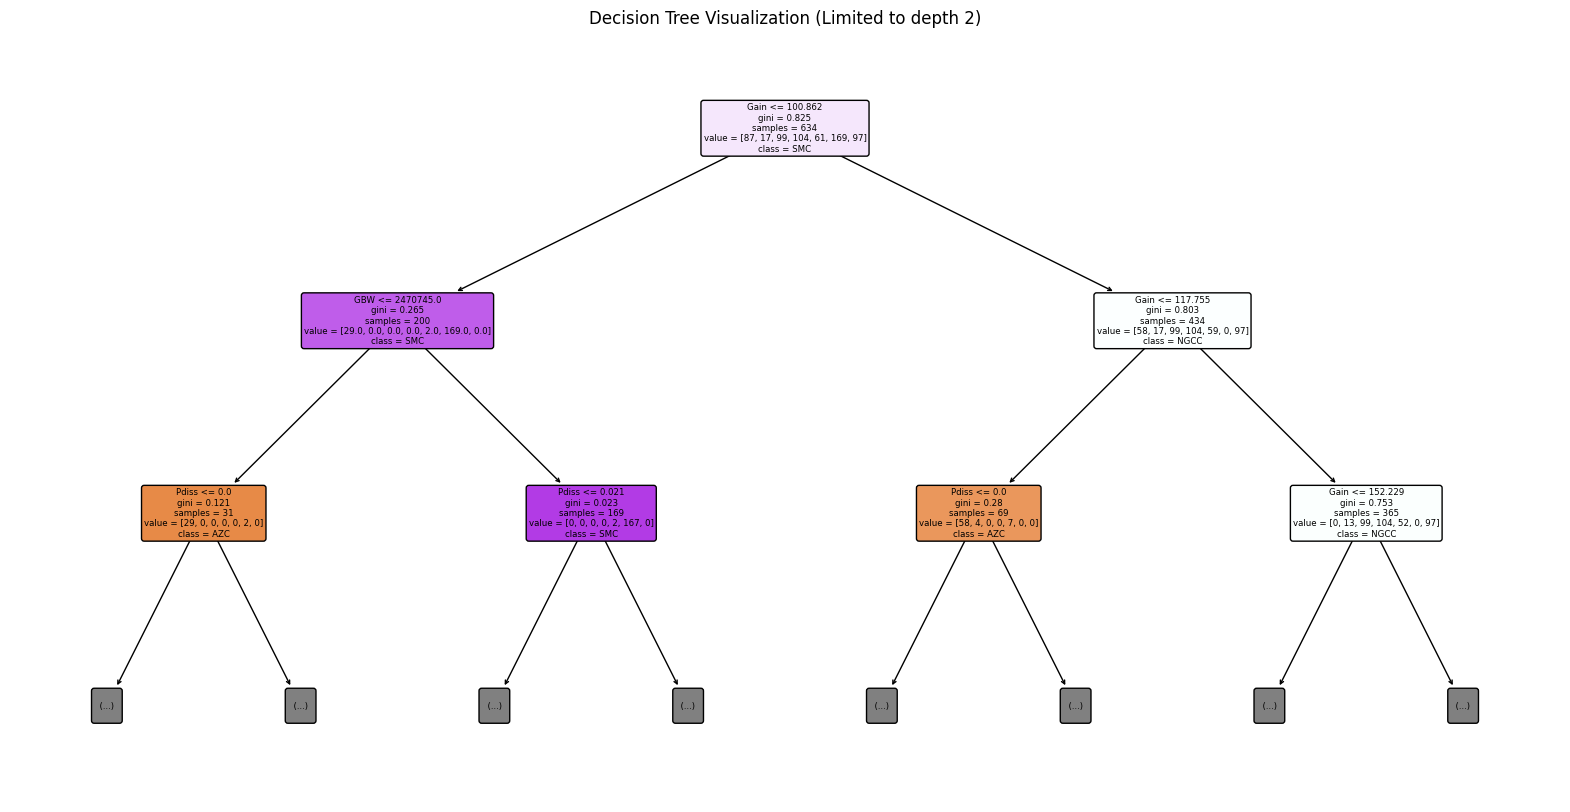

In [8]:
# CRT Tree
# Define parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'ccp_alpha': [0.0, 0.01, 0.02, 0.03]
}

# Use GridSearchCV to find the best parameters
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the data
print("-*-" * 10 + " CRT Tree Hyperparameter Tuning " + "-*-" * 10)
grid_search.fit(X, y_encoded)

# Display the best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# Create a new model with the best parameters
print("-*-" * 10 + " CRT Tree Best Model Evaluating " + "-*-" * 10)
best_CRT_Tree = DecisionTreeClassifier(**grid_search.best_params_)

# Evaluate the best model
best_CRT_Tree = evaluate_model(best_CRT_Tree, X, y_encoded)

# Visualize the decision tree (limited to max_depth=3 for clarity)
plt.figure(figsize=(20, 10))
plot_tree(best_CRT_Tree, max_depth=2, feature_names=['GBW', 'Gain', 'Pdiss'], 
          class_names=label_encoder.classes_, filled=True, rounded=True)
plt.title('Decision Tree Visualization (Limited to depth 2)')
plt.show()

# Add the model to our list of optimal models
optimal_model_list.append(('CRT Tree', best_CRT_Tree))

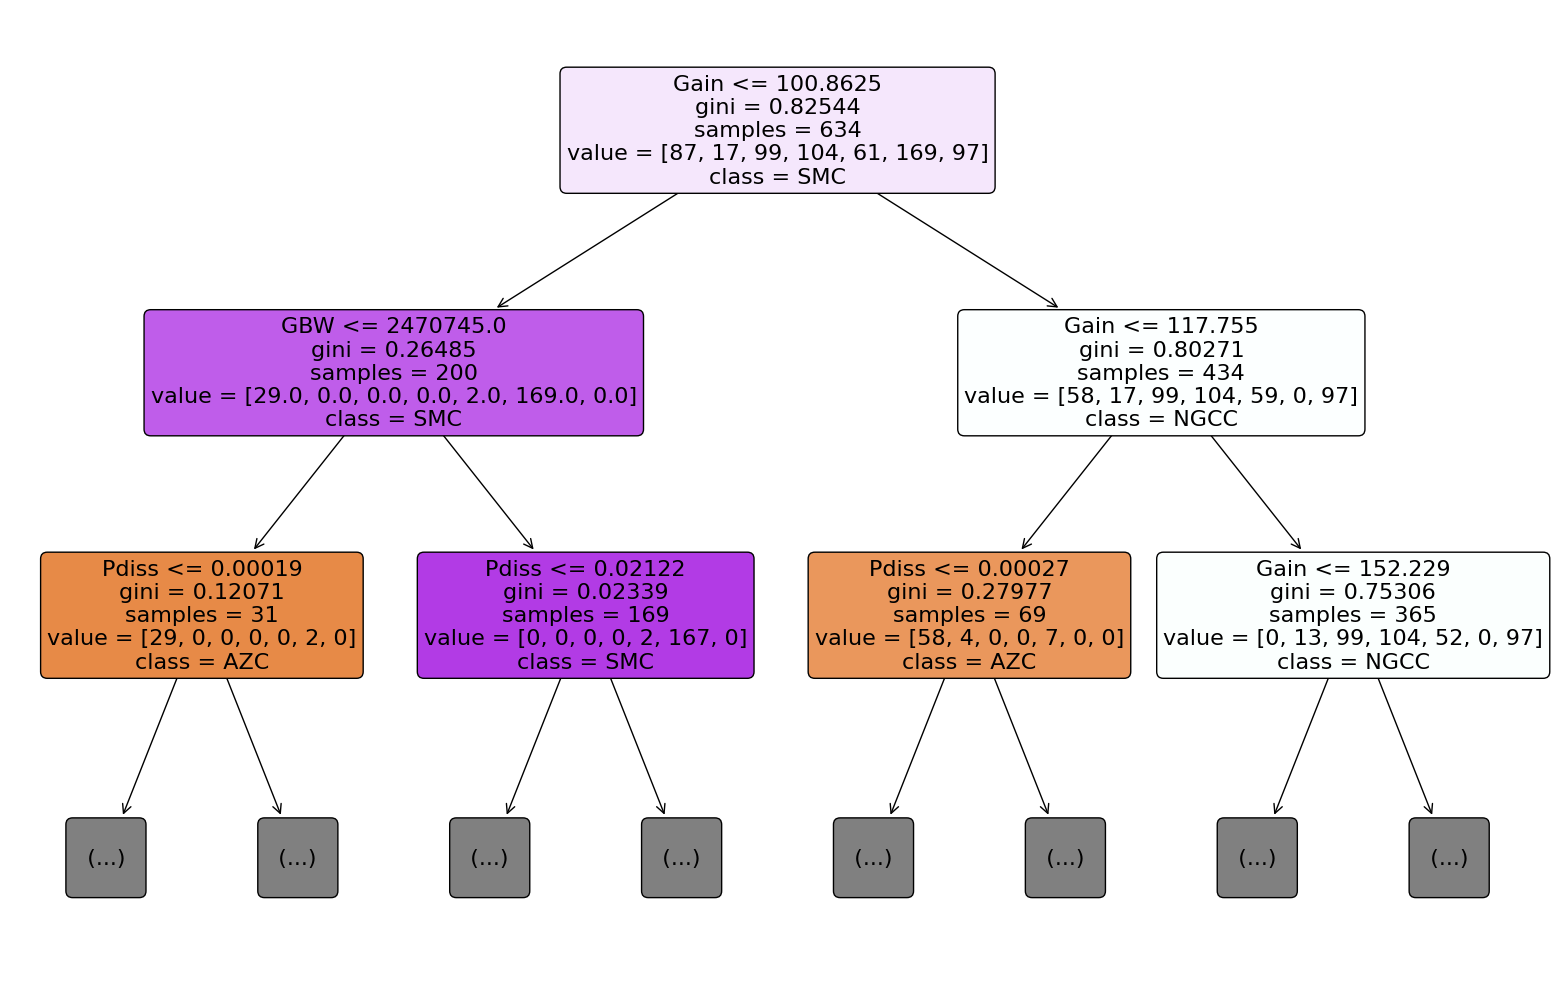

In [23]:
plt.figure(figsize=(16, 10))  # Increase the figure size as needed to fit larger fonts and complete information

plot_tree(
    best_CRT_Tree,
    max_depth=2,
    feature_names=['GBW', 'Gain', 'Pdiss'],
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=16,   # Increase the font size
    precision=5  
)

plt.tight_layout()  # Automatically adjust subplot parameters for a compact layout
plt.show()

# # Print detailed tree information
# print("Decision Tree Structure:")
# from sklearn.tree import export_text
# tree_structure = export_text(best_CRT_Tree, feature_names=['GBW', 'Gain', 'Pdiss'])
# print(tree_structure)

#### Random Forest
* Key parameters include `n_estimators` (the number of trees) and the depth of each tree. Increasing the number of trees generally improves stability until convergence (100–300 are sufficient for most tasks). You can fix a relatively large number of trees (for example, 200), then adjust `max_depth` or `min_samples_leaf` to control overfitting in individual trees. If training is too slow, increase the tree count gradually and monitor the error reduction to choose the final value. For this task's three features, `max_features` has little effect; the default $\sqrt{d}$ or all features are both reasonable. Enabling `bootstrap=True` lets each tree sample the training data and is already the default. Tune with grid or random search plus cross-validation—for example, try `max_depth` values 3, 5, and None (unlimited), `min_samples_leaf` values 1, 2, and 5, and `n_estimators` values 100, 200, and 500, then select the best validation combination.

-*--*--*--*--*--*--*--*--*--*- Random Forest Hyperparameter Tuning -*--*--*--*--*--*--*--*--*--*-
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.9493188351456068
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Number of Trees: {'n_estimators': 200}
Best Score: 0.9493188351456068
Final Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
-*--*--*--*--*--*--*--*--*--*- Random Forest Best Model Evaluating -*--*--*--*--*--*--*--*--*--*-
-------------------- Single Train-Test Split Evaluation --------------------
Test Accuracy: 0.9622641509433962

Classification Report:
              precision    recall  f1-score   support

         AZC       1.00      1.00      1.00        22
      DFCFC1       1.00      0.75      0.86         4
         IAC     

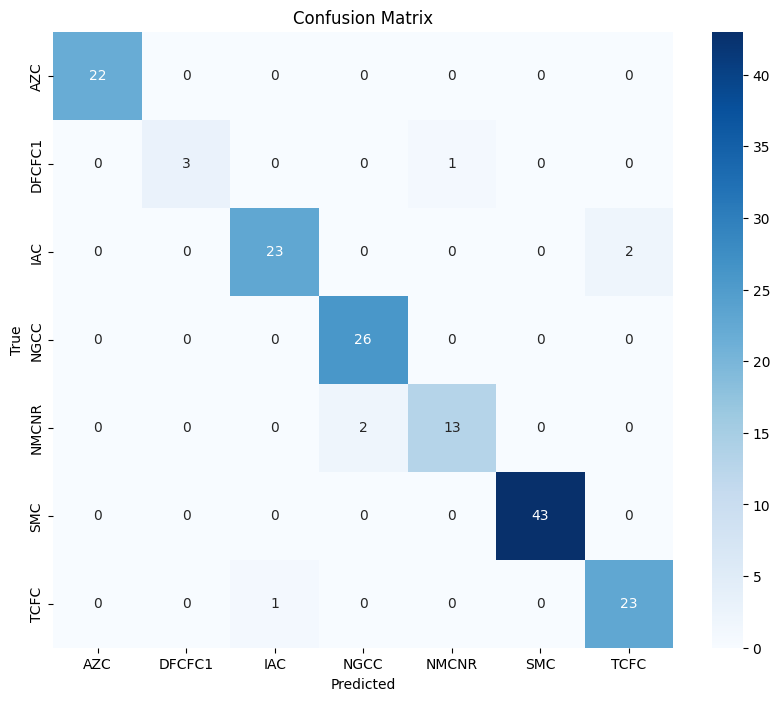

-------------------- Cross-Validation Evaluation --------------------
Test Accuracy: 0.9493 ± 0.0666
Test F1: 0.9429 ± 0.0767
Test Precision: 0.9490 ± 0.0670
Test Recall: 0.9418 ± 0.0798
Train Accuracy: 0.9984
Mean Fit Time: 0.1152s
Mean Score Time: 0.0055s
Final Model Trained on Entire Dataset
-*--*--*--*--*--*--*--*--*--*- Feature Importance Visulizing and Learning Curve -*--*--*--*--*--*--*--*--*--*-


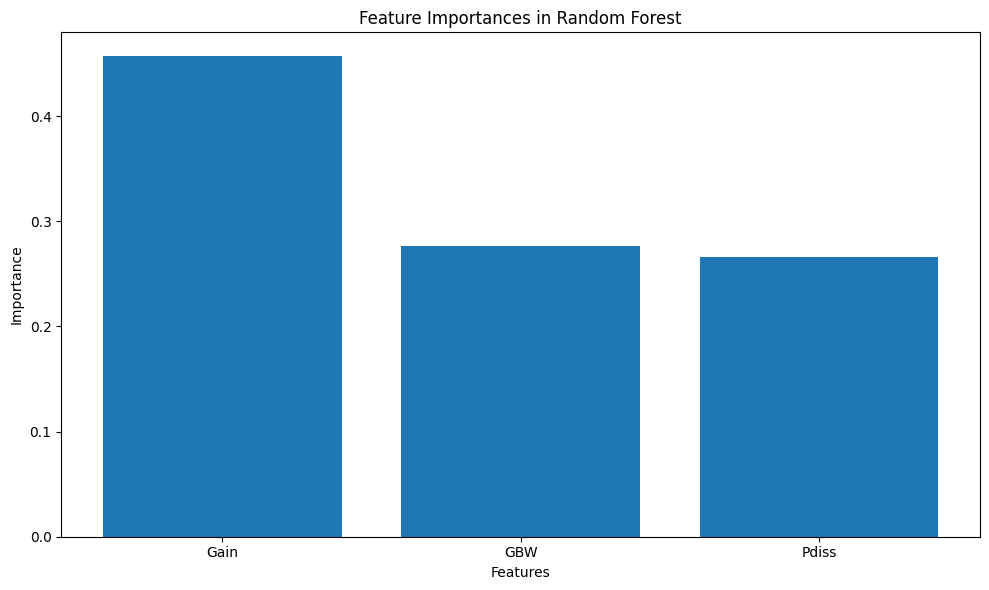

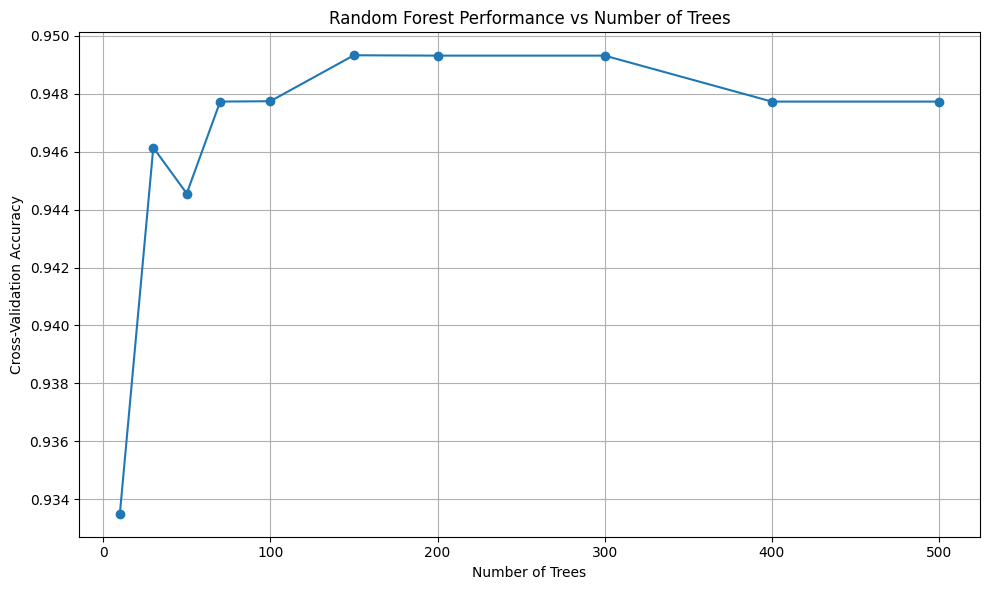

In [10]:
# Random Forest
print("-*-" * 10 + " Random Forest Hyperparameter Tuning " + "-*-" * 10)

# Define parameter grid for hyperparameter tuning
# First optimize for tree structure parameters with a fixed number of trees
param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],  # None means all features
    'n_estimators': [200]  # Fixed number of trees initially
}

# Use GridSearchCV to find the best parameters
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the data
grid_search.fit(X, y_encoded)

# Display the best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# Now that we've found the best tree structure parameters, let's optimize the number of trees
best_params = grid_search.best_params_.copy()
del best_params['n_estimators']  # Remove n_estimators to redefine it

param_grid = {
    'n_estimators': [50, 100, 200, 300, 400]
}

# Use GridSearchCV to find the best number of trees
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, **best_params),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the data
grid_search.fit(X, y_encoded)

# Display the best parameters
print("Best Number of Trees:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# Combine the best parameters
best_params.update(grid_search.best_params_)
print("Final Best Parameters:", best_params)

# Create a new model with the best parameters
print("-*-" * 10 + " Random Forest Best Model Evaluating " + "-*-" * 10)
best_RF = RandomForestClassifier(random_state=42, **best_params)

# Evaluate the best model
best_RF = evaluate_model(best_RF, X, y_encoded)

print("-*-" * 10 + " Feature Importance Visulizing and Learning Curve " + "-*-" * 10)
# Visualize feature importance
plt.figure(figsize=(10, 6))
importances = best_RF.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = ['GBW', 'Gain', 'Pdiss']

plt.title('Feature Importances in Random Forest')
plt.bar(range(len(indices)), importances[indices], align='center')
plt.xticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# Plot learning curve to see how performance changes with n_estimators
n_estimators_range = [10, 30, 50, 70, 100, 150, 200, 300, 400, 500]
accuracies = []

for n_estimators in n_estimators_range:
    # Create a model with the current number of trees
    rf = RandomForestClassifier(random_state=42, n_estimators=n_estimators, **{k: v for k, v in best_params.items() if k != 'n_estimators'})
    # Perform cross-validation
    scores = cross_validate(rf, X, y_encoded, cv=5, scoring='accuracy')
    # Store the mean accuracy
    accuracies.append(scores['test_score'].mean())

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, accuracies, marker='o')
plt.title('Random Forest Performance vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Cross-Validation Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

# Add the model to our list of optimal models
optimal_model_list.append(('Random Forest', best_RF))

#### XGBoost
* XGBoost is relatively complex and should be tuned in stages. A typical approach is to start with a medium `max_depth` (4–6 levels), a small `learning_rate` (0.05–0.1), and a suitable `n_estimators` (100–200), then check for overfitting. Adjust as needed: if overfitting appears (validation error rises), reduce `max_depth` or increase the randomness from `subsample` (for example, 0.8) to regularize; if the model is weak (both training and validation accuracy are low), increase the learning rate or the number of trees. XGBoost also supports early stopping: monitor validation error and stop after several rounds (for example, 10) without improvement to obtain the best iteration count. For hyperparameter search, first balance `max_depth` and `learning_rate`, then fine-tune `gamma` (minimum split gain), `reg_lambda` (L2 regularization), and other details to improve generalization. Because there are many parameters, exhaustive grid search is expensive; hierarchical tuning or Bayesian optimization is often more efficient.

In [11]:
# Start with a medium max_depth (4–6 levels) and small learning_rate (0.05–0.1), together with a suitable n_estimators (100–200), and check for overfitting.
# XGBoost
print("-*-" * 10 + " XGBoost Initial Evaluation " + "-*-" * 10)

# Initial model with moderate parameters
xgb_model = xgb.XGBClassifier(
    max_depth=5,              # Moderate tree depth
    learning_rate=0.1,        # Moderate learning rate     
    n_estimators=100,         # Moderate number of trees
    objective='multi:softmax',  # Multiclass classification
    random_state=42
)

# Perform cross-validation to check for overfitting
scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}
cv_scores = cross_validate(xgb_model, X, y_encoded, cv=5, scoring=scoring, return_train_score=True)

# To check for overfitting, we can compare train and test accuracies
print(f"Train Accuracy: {cv_scores['train_accuracy'].mean():.4f}")
print(f"Test Accuracy: {cv_scores['test_accuracy'].mean():.4f} ± {cv_scores['test_accuracy'].std():.4f}")

# Large gap: if training accuracy is much higher than test accuracy (gap >5–10%), overfitting may be present
# Normal gap: training accuracy slightly above test accuracy (gap 3–5%) is usually normal

-*--*--*--*--*--*--*--*--*--*- XGBoost Initial Evaluation -*--*--*--*--*--*--*--*--*--*-
Train Accuracy: 1.0000
Test Accuracy: 0.9430 ± 0.0709


-*--*--*--*--*--*--*--*--*--*- XGBoost Hyperparameter Tuning -*--*--*--*--*--*--*--*--*--*-
-*--*--*--*--*--*--*--*--*--*- XGBoost Hyperparameter Tuning Stage 1: Tree Structure -*--*--*--*--*--*--*--*--*--*-
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}
Best Score: 0.942994625671791
-*--*--*--*--*--*--*--*--*--*- XGBoost Hyperparameter Tuning Stage 2: Early Stopping -*--*--*--*--*--*--*--*--*--*-
[0]	validation_0-mlogloss:1.69510	validation_1-mlogloss:1.68966
[1]	validation_0-mlogloss:1.50587	validation_1-mlogloss:1.49670
[2]	validation_0-mlogloss:1.35575	validation_1-mlogloss:1.34540
[3]	validation_0-mlogloss:1.23168	validation_1-mlogloss:1.22148
[4]	validation_0-mlogloss:1.12687	validation_1-mlogloss:1.11855
[5]	validation_0-mlogloss:1.03590	validation_1-mlogloss:1.02491
[6]	validation_0-mlogloss:0.95223	validation_1-mlogloss:0

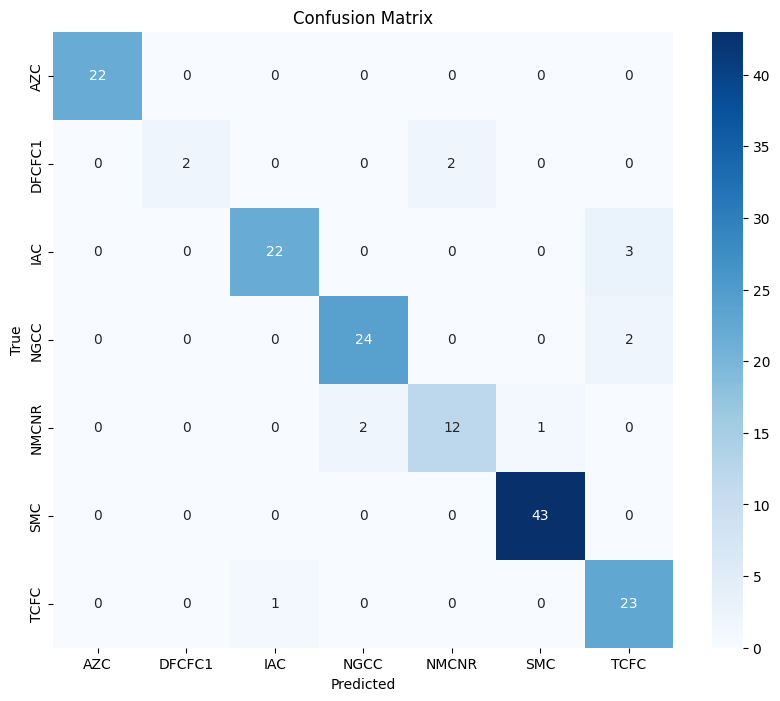

-------------------- Cross-Validation Evaluation --------------------
Test Accuracy: 0.9414 ± 0.0741
Test F1: 0.9270 ± 0.0990
Test Precision: 0.9336 ± 0.0948
Test Recall: 0.9247 ± 0.1019
Train Accuracy: 0.9996
Mean Fit Time: 0.3754s
Mean Score Time: 0.0190s
Final Model Trained on Entire Dataset


In [12]:
# If overfitting appears (validation error rises), reduce max_depth or increase the randomness from subsample (for example, 0.8) to regularize; if the model is weak (both training and validation accuracy are low), increase the learning rate or the number of trees. XGBoost also supports early stopping: monitor validation error and stop after several rounds (for example, 10) without improvement to obtain the best iteration count. For hyperparameter search, first balance max_depth and learning_rate, then fine-tune gamma (minimum split gain), reg_lambda (L2 regularization), and other details to improve generalization.

print("-*-" * 10 + " XGBoost Hyperparameter Tuning " + "-*-" * 10)

# Split data for early stopping evaluation
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# First stage: Find best tree structure with regularization
print("-*-" * 10 + " XGBoost Hyperparameter Tuning Stage 1: Tree Structure " + "-*-" * 10)
param_grid_1 = {
    'max_depth': [3, 4, 5],                    # Reduce depth to control overfitting
    'min_child_weight': [1, 3, 5],             # Higher values prevent overfitting
    'subsample': [0.8, 0.9],                   # Random sampling of rows
    'colsample_bytree': [0.8, 0.9, 1.0],       # Random sampling of columns
    'learning_rate': [0.1],                    # Fixed for now
    'n_estimators': [100]                      # Fixed for now
}

# Create XGBoost model
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    random_state=42,
    reg_lambda=1,                              # L2 regularization
    reg_alpha=0                                # L1 regularization
)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_1,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y_encoded)
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# Second stage: Fine-tune learning rate and regularization with early stopping
print("-*-" * 10 + " XGBoost Hyperparameter Tuning Stage 2: Early Stopping " + "-*-" * 10)

best_params = grid_search.best_params_.copy()
del best_params['n_estimators']  # Remove n_estimators to redefine it

# Use early stopping with a validation set
eval_set = [(X_train, y_train), (X_val, y_val)]

# Create a new model with best parameters from first stage + early stopping
xgb_tuned = xgb.XGBClassifier(
    objective='multi:softmax',
    random_state=42,
    **best_params,
    n_estimators=500,                          # Intentionally high, will be reduced by early stopping
    early_stopping_rounds=10,                  # Stop if no improvement after 10 rounds
    reg_lambda=1,                              # L2 regularization
    reg_alpha=0.01                             # Light L1 regularization
)

# Fit with early stopping
xgb_tuned.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=True
)

print(f"Best iteration: {xgb_tuned.best_iteration}")
print(f"Best score: {xgb_tuned.best_score}")

# Evaluate the final model
print("-*-" * 10 + " XGBoost Best Model Evaluating " + "-*-" * 10)
best_XGB = xgb.XGBClassifier(
    objective='multi:softmax',
    random_state=42,
    **best_params,
    n_estimators=xgb_tuned.best_iteration,     # Use the optimal number of trees
    reg_lambda=1,
    reg_alpha=0.01
)

# Evaluate the best model
best_XGB = evaluate_model(best_XGB, X, y_encoded)

# Add the model to our list of optimal models
optimal_model_list.append(('XGBoost', best_XGB))


### SVM
* Tune `C` (the penalty coefficient) and kernel parameters such as `gamma` (RBF kernel width). A grid search is typical: try combinations with C in ${0.1, 1, 10, 100}$ and gamma in ${0.001, 0.01, 0.1, 1}$. C controls tolerance for misclassification: a small value yields a wider margin but higher training error, while a large value can overfit. gamma controls the RBF kernel's “influence range”: a large value focuses on local regions (overfitting), whereas a small value makes the model overly rigid and nearly linear. Use cross-validation accuracy to select C and gamma. If the dataset is somewhat large, kernel SVM can be slow; consider an approximation (such as sklearn's LinearSVC with a kernel-feature map) or reducing feature dimensionality (the dimensionality here is already low). Standardizing input features is essential for SVM classification.

-*--*--*--*--*--*--*--*--*--*- SVM Hyperparameter Tuning -*--*--*--*--*--*--*--*--*--*-
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Parameters: {'C': 100, 'decision_function_shape': 'ovo', 'gamma': 1, 'kernel': 'poly'}
Best Score: 0.922559680039995
-*--*--*--*--*--*--*--*--*--*- SVM Best Model Evaluating -*--*--*--*--*--*--*--*--*--*-
-------------------- Single Train-Test Split Evaluation --------------------
Test Accuracy: 0.8930817610062893

Classification Report:
              precision    recall  f1-score   support

         AZC       0.96      1.00      0.98        22
      DFCFC1       0.75      0.75      0.75         4
         IAC       0.70      0.76      0.73        25
        NGCC       0.92      0.92      0.92        26
       NMCNR       0.93      0.87      0.90        15
         SMC       1.00      1.00      1.00        43
        TCFC       0.82      0.75      0.78        24

    accuracy                           0.89       159
   macro avg     

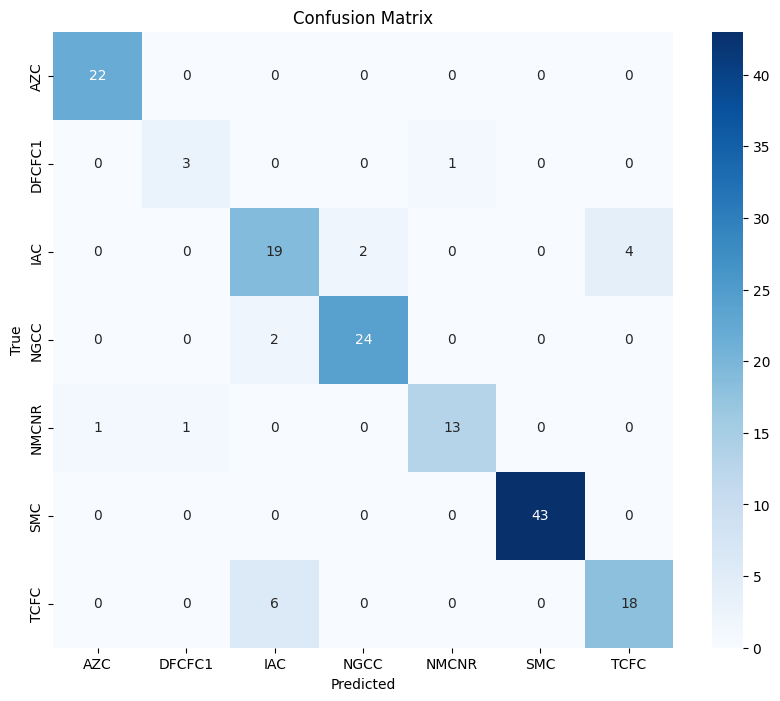

-------------------- Cross-Validation Evaluation --------------------
Test Accuracy: 0.9210 ± 0.0560
Test F1: 0.9106 ± 0.0714
Test Precision: 0.9138 ± 0.0658
Test Recall: 0.9143 ± 0.0736
Train Accuracy: 0.9472
Mean Fit Time: 0.0320s
Mean Score Time: 0.0026s
Final Model Trained on Entire Dataset


In [13]:
# Multiclass SVM
# For SVM, also convert the wide-dynamic-range GBW to dB
X_db = X.copy()
X_db[:, 0] = 20 * np.log10(X[:, 0])

print("-*-" * 10 + " SVM Hyperparameter Tuning " + "-*-" * 10)

# 1. First standardize the data (SVM is highly sensitive to feature scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_db)

# 2. Use grid search to find the best parameters
param_grid = {
    'C': [0.1, 1, 10, 100],            # Penalty parameter
    'gamma': [0.001, 0.01, 0.1, 1],    # RBF kernel parameter
    'kernel': ['rbf', 'poly', 'linear'],  # Kernel type
    'decision_function_shape': ['ovo', 'ovr']  # Multiclass strategy
}

# Create the SVM model
svm_model = SVC(probability=True, random_state=42)

# Grid search
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)

# Run grid search
grid_search.fit(X_scaled, y_encoded)

# Print the best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# 3. Create the final model with the best parameters
print("-*-" * 10 + " SVM Best Model Evaluating " + "-*-" * 10)
best_SVM = SVC(probability=True, random_state=42, **grid_search.best_params_)

# 4. Evaluate model performance (using standardized data)
# Create a Pipeline so evaluation also applies dB conversion and standardization
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
# Create a custom transformer for dB conversion
class DbTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_db = X.copy()
        X_db[:, 0] = 20 * np.log10(X_db[:, 0])  # Convert GBW to dB
        return X_db

# Create a pipeline that includes dB conversion, standardization, and SVM
svm_pipeline = Pipeline([
    ('db_transform', DbTransformer()),  # First convert GBW to dB
    ('scaler', StandardScaler()),       # Then standardize all features
    ('svm', best_SVM)                   # Finally apply SVM
])

# Use the unified evaluation function
best_SVM_pipeline = evaluate_model(svm_pipeline, X, y_encoded)

# 5. Add the model to the best-model list
optimal_model_list.append(('SVM', best_SVM_pipeline))


### KNN
* Choose an appropriate neighbor count `k`. `k=1` memorizes training details but is sensitive to noise; larger k values smooth the classification boundary. Test odd neighbor counts (to avoid ties) on the validation set and plot accuracy; increase k from 1 to a fraction of the training-set size, for example 1, 3, 5, 7, …, until validation accuracy declines, then select the best value. Euclidean distance is usually sufficient; if metric scales differ greatly, consider a weighted or Mahalanobis distance (which requires covariance estimation). The three metrics here have different units (gain in dB, bandwidth in Hz, and power in W), so normalize or standardize each dimension before KNN—for example, subtract the mean and divide by the standard deviation—so each metric contributes comparably to the distance.

-*--*--*--*--*--*--*--*--*--*- KNN Hyperparameter Tuning -*--*--*--*--*--*--*--*--*--*-
Fitting 5 folds for each of 198 candidates, totalling 990 fits
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
Best Score: 0.947769028871391
-*--*--*--*--*--*--*--*--*--*- KNN Best Model Evaluating -*--*--*--*--*--*--*--*--*--*-
-------------------- Single Train-Test Split Evaluation --------------------
Test Accuracy: 0.9559748427672956

Classification Report:
              precision    recall  f1-score   support

         AZC       0.92      1.00      0.96        22
      DFCFC1       1.00      1.00      1.00         4
         IAC       0.96      1.00      0.98        25
        NGCC       0.92      0.92      0.92        26
       NMCNR       1.00      0.87      0.93        15
         SMC       1.00      1.00      1.00        43
        TCFC       0.91      0.88      0.89        24

    accuracy                           0.96       159
   macro avg      

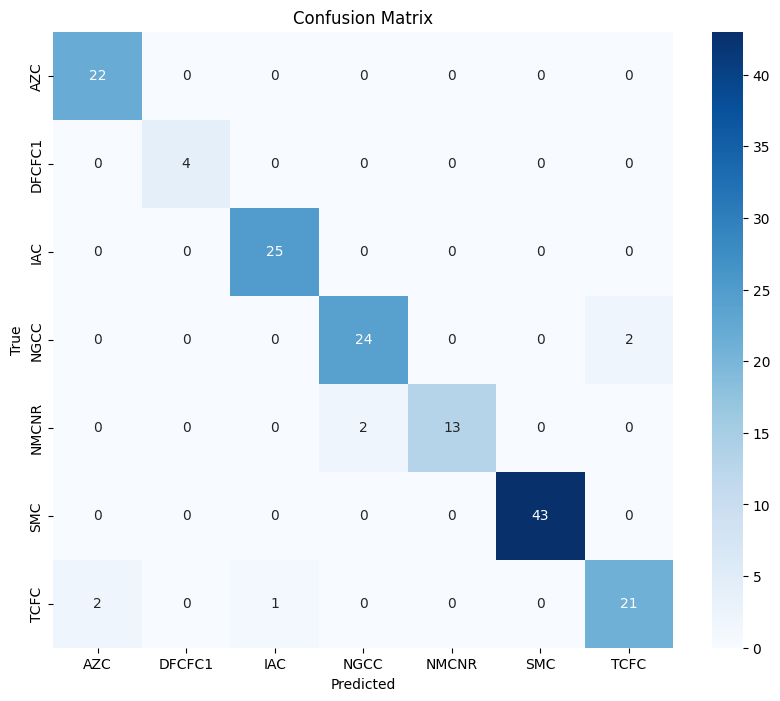

-------------------- Cross-Validation Evaluation --------------------
Test Accuracy: 0.9478 ± 0.0593
Test F1: 0.9376 ± 0.0663
Test Precision: 0.9425 ± 0.0568
Test Recall: 0.9399 ± 0.0718
Train Accuracy: 1.0000
Mean Fit Time: 0.0007s
Mean Score Time: 0.0026s
Final Model Trained on Entire Dataset


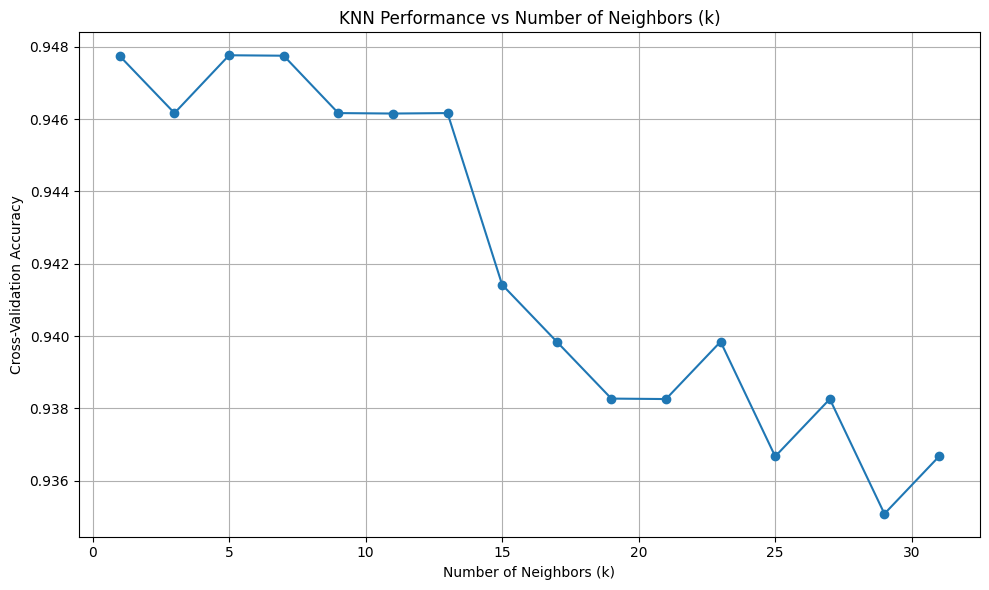

In [14]:
# KNN - K-Nearest Neighbors
print("-*-" * 10 + " KNN Hyperparameter Tuning " + "-*-" * 10)

# First, let's convert GBW to dB scale like we did for SVM
X_db = X.copy()
X_db[:, 0] = 20 * np.log10(X[:, 0])  # Convert GBW to dB scale

# Scale features for better distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_db)

# Perform grid search to find optimal k and other parameters
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 21, 25, 31],  # Try a range of k values (odd to avoid ties)
    'weights': ['uniform', 'distance'],                      # Try uniform weights vs distance-weighted
    'metric': ['euclidean', 'manhattan', 'minkowski'],       # Different distance metrics
    'p': [1, 2, 3]                                           # p parameter for Minkowski (1=Manhattan, 2=Euclidean)
}

# Create KNN model
knn = KNeighborsClassifier()

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_scaled, y_encoded)

# Display the best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# Create a pipeline like we did for SVM to ensure consistent preprocessing
# Create a KNN pipeline that includes dB conversion, standardization, and KNN
knn_pipeline = Pipeline([
    ('db_transform', DbTransformer()),  # First convert GBW to dB
    ('scaler', StandardScaler()),       # Then standardize all features
    ('knn', KNeighborsClassifier(**grid_search.best_params_))  # Finally apply KNN with best parameters
])

# Evaluate the best model
print("-*-" * 10 + " KNN Best Model Evaluating " + "-*-" * 10)
best_KNN_pipeline = evaluate_model(knn_pipeline, X, y_encoded)

# Visualize the effect of k on model performance
k_range = list(range(1, 32, 2))  # Odd numbers from 1 to 31
k_scores = []

for k in k_range:
    knn_test = Pipeline([
        ('db_transform', DbTransformer()),
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k, 
                                    weights=grid_search.best_params_['weights'],
                                    metric=grid_search.best_params_['metric'],
                                    p=grid_search.best_params_['p']))
    ])
    scores = cross_validate(knn_test, X, y_encoded, cv=5, scoring='accuracy')
    k_scores.append(scores['test_score'].mean())

# Plot k vs. accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores, marker='o')
plt.title('KNN Performance vs Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

# Add the model to our list of optimal models
optimal_model_list.append(('KNN', best_KNN_pipeline))

### Neural Network
* First choose the network architecture. For three inputs and eight output classes, start with a small network, such as two hidden layers: try 20–50 units in the first and 10–30 in the second (progressive compression helps learn combined features). Use ReLU activations and a Softmax output (with cross-entropy loss). Hyperparameters include the learning rate (which affects convergence speed and the final point); try 0.001–0.01. For regularization, consider an L2 term or a Dropout layer (for example, dropout probability 0.5) to prevent overfitting. A medium batch size (32 or 64) is generally stable. Tune by monitoring training and validation loss curves: if training loss is much lower than validation loss, the model is overfitting, so strengthen regularization or reduce network size; if both remain high, increase capacity or train for more epochs. For training hyperparameters such as the learning rate, a decay schedule (for example, multiply it by 0.1 every few epochs) can refine convergence. Neural-network randomness can make results vary slightly, so run multiple trials and average them or choose the best-performing weights. Overall, neural-network tuning is involved; with limited resources, first verify feasibility with a simple model on a small dataset before investing in further NN optimization.

-*--*--*--*--*--*--*--*--*--*- Neural Network Implementation with MLPClassifier -*--*--*--*--*--*--*--*--*--*-
-*--*--*--*--*--*--*--*--*--*- Neural Network Grid Search -*--*--*--*--*--*--*--*--*--*-
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'alpha': 0.001, 'batch_size': 32, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.01, 'max_iter': 500}
Best Score: 0.8862142232220972
-*--*--*--*--*--*--*--*--*--*- Neural Network Best Model Evaluating -*--*--*--*--*--*--*--*--*--*-
-------------------- Single Train-Test Split Evaluation --------------------
Test Accuracy: 0.8805031446540881

Classification Report:
              precision    recall  f1-score   support

         AZC       0.92      1.00      0.96        22
      DFCFC1       1.00      0.50      0.67         4
         IAC       0.88      0.60      0.71        25
        NGCC       0.89      0.92      0.91        26
       NMCNR       0.85      0.73      0.79        15
         SMC      

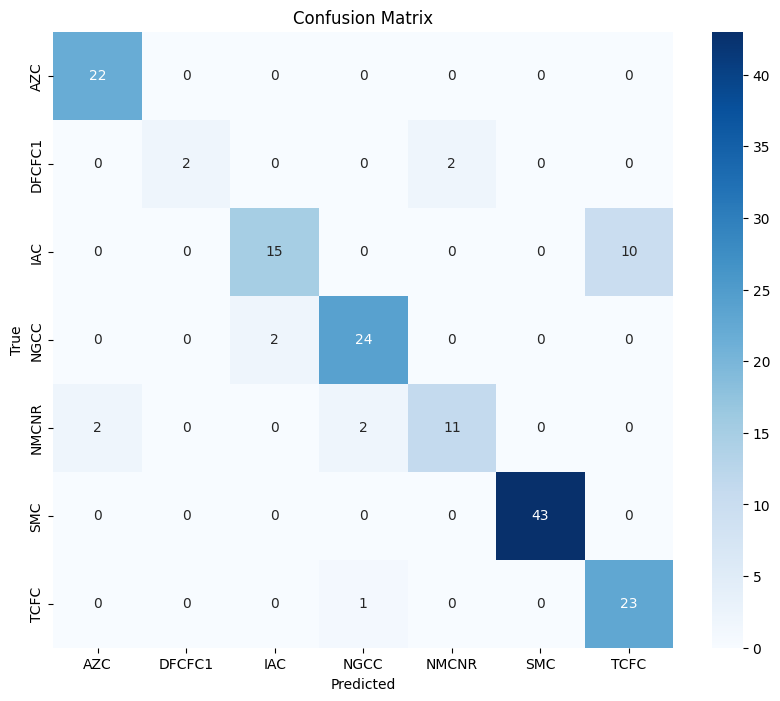

-------------------- Cross-Validation Evaluation --------------------
Test Accuracy: 0.9099 ± 0.0534
Test F1: 0.8910 ± 0.0574
Test Precision: 0.9002 ± 0.0690
Test Recall: 0.8902 ± 0.0503
Train Accuracy: 0.9164
Mean Fit Time: 0.1485s
Mean Score Time: 0.0038s
Final Model Trained on Entire Dataset


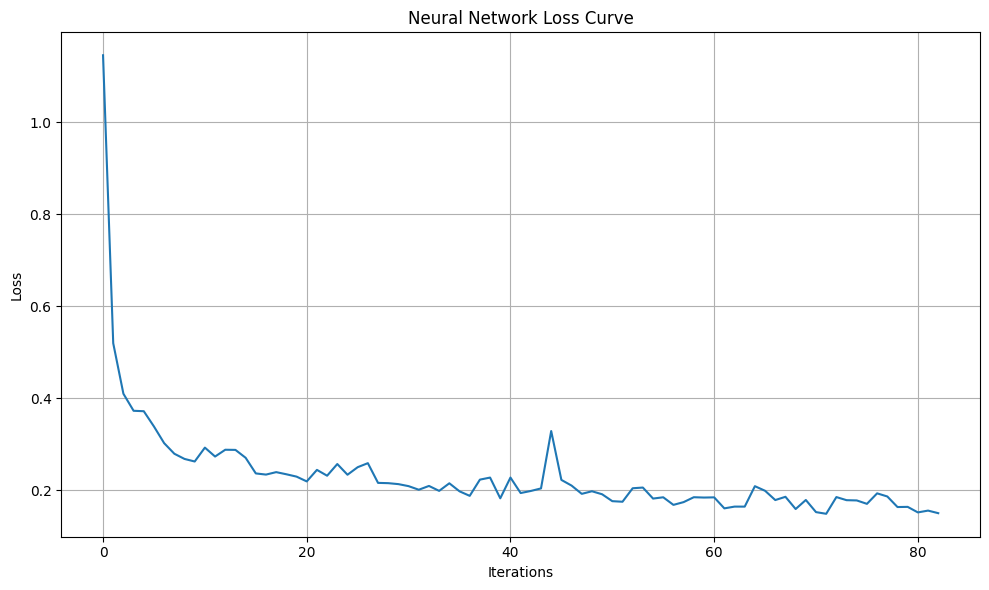

In [15]:
# Neural Network using MLPClassifier
print("-*-" * 10 + " Neural Network Implementation with MLPClassifier " + "-*-" * 10)

# First, let's convert GBW to dB scale like we did for SVM/KNN
# Except for decision trees, the other models should generally be standardized
X_db = X.copy()
X_db[:, 0] = 20 * np.log10(X[:, 0])  # Convert GBW to dB scale

# Scale features for better neural network performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_db)

# Create a grid search to find the best hyperparameters
param_grid = {
    'hidden_layer_sizes': [(30,15), (50,20), (50,30), (100,50)],  # (first_layer, second_layer)
    'alpha': [0.0001, 0.001, 0.01],             # L2 regularization parameter
    'learning_rate_init': [0.001, 0.01],        # Initial learning rate
    'batch_size': [32, 64, 'auto'],             # Batch size
    'max_iter': [500]                           # Maximum number of iterations
}

# Create the neural network model
mlp = MLPClassifier(
    activation='relu',                  # ReLU activation function
    solver='adam',                      # Adam optimizer
    early_stopping=True,                # Use early stopping
    validation_fraction=0.2,            # Fraction of training data for validation
    random_state=42,                    # For reproducibility
    verbose=False,                      # Don't print progress
)

# Perform grid search
print("-*-" * 10 + " Neural Network Grid Search " + "-*-" * 10)
grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=5,                  # Use 5-fold cross-validation for speed
    scoring='accuracy',
    n_jobs=-1,             # Use all available CPU cores
    verbose=1
)

# Fit the grid search to find the best hyperparameters
grid_search.fit(X_scaled, y_encoded)

# Display the best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# Create a pipeline that includes dB conversion, standardization, and Neural Network
nn_pipeline = Pipeline([
    ('db_transform', DbTransformer()),  # First convert GBW to dB
    ('scaler', StandardScaler()),       # Then standardize all features
    ('mlp', MLPClassifier(
        **grid_search.best_params_
    ))  # Neural network with best parameters
])

# Evaluate the best model
print("-*-" * 10 + " Neural Network Best Model Evaluating " + "-*-" * 10)
best_NN_pipeline = evaluate_model(nn_pipeline, X, y_encoded)

# Plot the loss curve for the best MLP model
plt.figure(figsize=(10, 6))
plt.plot(best_NN_pipeline.named_steps['mlp'].loss_curve_)
plt.title('Neural Network Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

# Add the model to our list of optimal models
optimal_model_list.append(('Neural Network', best_NN_pipeline))

## Overall Model Comparison

Compare the performance of the models after hyperparameter tuning:
* Decision tree: For medium-sized datasets (hundreds to thousands of samples), random forests/XGBoost often approach deep-learning performance with lower training difficulty and time cost.
  * Standard decision tree: highly interpretable, but generally less accurate.
  * Random forest: better performance, although some interpretability is lost; requires tuning; 100–200 trees are recommended.
  * XGBoost: similar to random forests.
* SVM: theoretically mature with good generalization, but multiclass problems require multiple models.
* KNN: simple and easy to use, requires no training, and offers moderate performance.
* Neural network: often performs well, but requires substantial data and is difficult to interpret, so it may not be suitable.

In [16]:
# Display all models
print("-*-" * 10 + " All Optimal Models " + "-*-" * 10)
for model_name, model in optimal_model_list:
    print(f"Model: {model_name}")
    print(model)
    print("-*-" * 10)

-*--*--*--*--*--*--*--*--*--*- All Optimal Models -*--*--*--*--*--*--*--*--*--*-
Model: CRT Tree
DecisionTreeClassifier()
-*--*--*--*--*--*--*--*--*--*-
Model: Random Forest
RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)
-*--*--*--*--*--*--*--*--*--*-
Model: XGBoost
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=214,
            

Evaluating CRT Tree with 5-fold cross-validation...
Evaluating Random Forest with 5-fold cross-validation...
Evaluating XGBoost with 5-fold cross-validation...


/tmp/ipykernel_3073523/3948542131.py:52: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_row], ignore_index=True)


Evaluating SVM with 5-fold cross-validation...
Evaluating KNN with 5-fold cross-validation...
Evaluating Neural Network with 5-fold cross-validation...

Cross-Validation Results:
            Model  Accuracy  Accuracy_std  F1_macro F1_macro_std  Precision_macro Precision_macro_std  Recall_macro Recall_macro_std  Fit_Time  Score_Time
0        CRT Tree  0.928696      0.103537  0.922106          NaN         0.934277                 NaN      0.922538              NaN  0.001214    0.003168
1   Random Forest  0.949319      0.066561  0.942904          NaN         0.949020                 NaN      0.941838              NaN  0.125456    0.006128
2         XGBoost  0.941407      0.074109  0.927006          NaN         0.933594                 NaN      0.924697              NaN  0.084039    0.003674
3             SVM  0.920972      0.055986  0.910566          NaN         0.913762                 NaN      0.914322              NaN  0.033574    0.002476
4             KNN  0.947769      0.059345  0.9

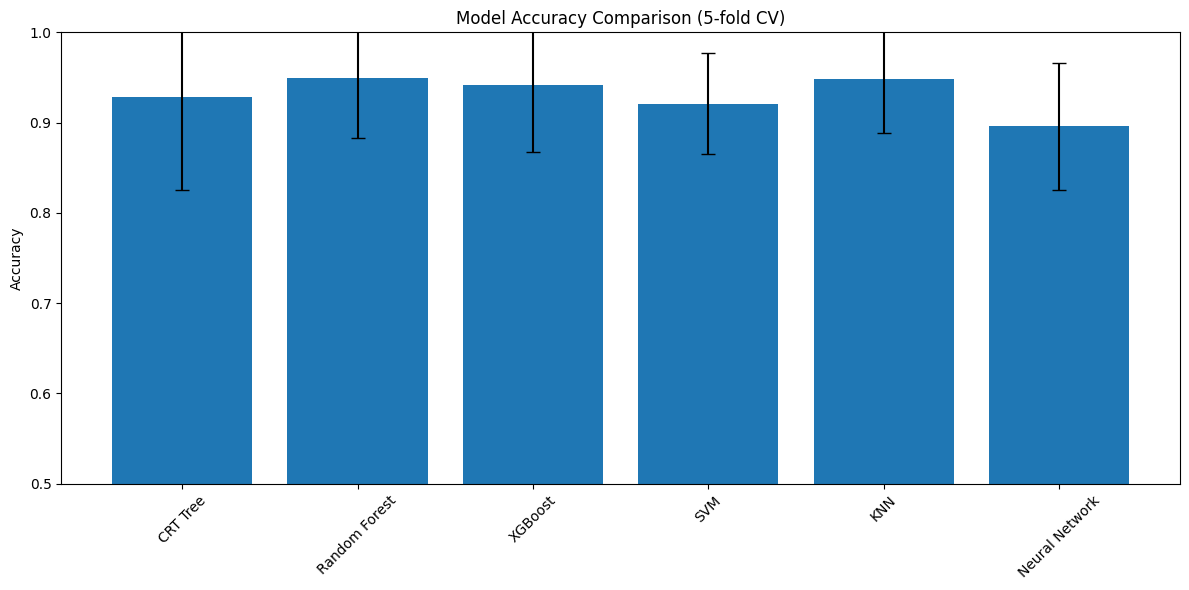

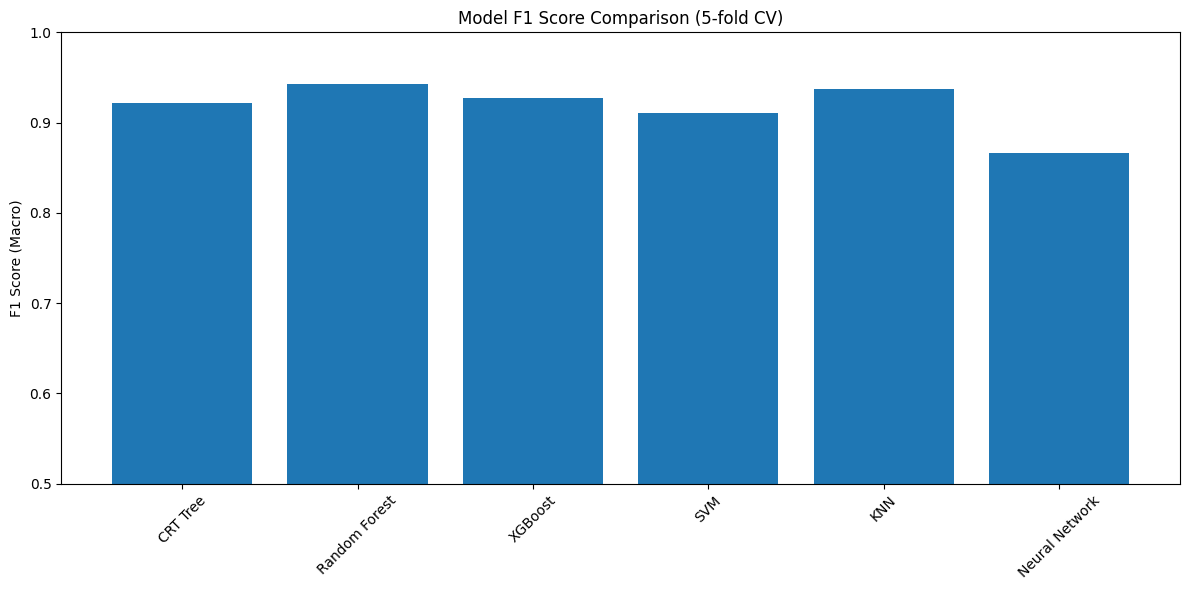

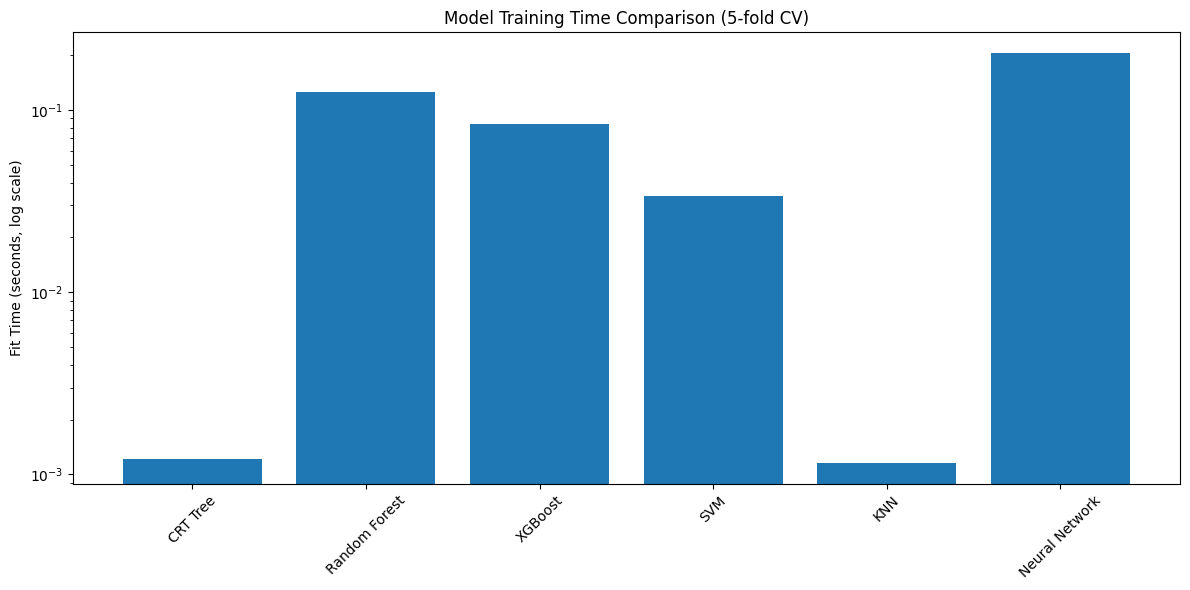

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate
import seaborn as sns

import matplotlib.pyplot as plt

# Prepare a DataFrame to store the results
results_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Accuracy_std', 
                                  'F1_macro', 'F1_macro_std',
                                  'Precision_macro', 'Precision_macro_std',
                                  'Recall_macro', 'Recall_macro_std',
                                  'Fit_Time', 'Score_Time'])

# Scoring metrics for cross-validation
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

# Perform 5-fold cross-validation for each model
for model_name, model in optimal_model_list:
    print(f"Evaluating {model_name} with 5-fold cross-validation...")
    
    # Perform cross-validation
    cv_results = cross_validate(
        model, 
        X, 
        y_encoded, 
        cv=5, 
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    
    # Extract and store results
    new_row = pd.DataFrame({
        'Model': [model_name],
        'Accuracy': [cv_results['test_accuracy'].mean()],
        'Accuracy_std': [cv_results['test_accuracy'].std()],
        'F1_macro': [cv_results['test_f1_macro'].mean()],
        # 'F1_macro_std': [cv_results['test_f1_macro'].std()],
        'Precision_macro': [cv_results['test_precision_macro'].mean()],
        # 'Precision_macro_std': [cv_results['test_precision_macro'].std()],
        'Recall_macro': [cv_results['test_recall_macro'].mean()],
        # 'Recall_macro_std': [cv_results['test_recall_macro'].std()],
        'Fit_Time': [cv_results['fit_time'].mean()],
        'Score_Time': [cv_results['score_time'].mean()]
    })
    results_df = pd.concat([results_df, new_row], ignore_index=True)

# Display the results
print("\nCross-Validation Results:")
print(results_df.to_string())

# Plot the accuracy comparison
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df))
plt.bar(x, results_df['Accuracy'], yerr=results_df['Accuracy_std'], capsize=5)
plt.xticks(x, results_df['Model'], rotation=45)
plt.title('Model Accuracy Comparison (5-fold CV)')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)  # Adjust as needed
plt.tight_layout()
plt.show()

# Plot the F1 score comparison
plt.figure(figsize=(12, 6))
plt.bar(x, results_df['F1_macro'], yerr=results_df['F1_macro_std'], capsize=5)
plt.xticks(x, results_df['Model'], rotation=45)
plt.title('Model F1 Score Comparison (5-fold CV)')
plt.ylabel('F1 Score (Macro)')
plt.ylim(0.5, 1.0)  # Adjust as needed
plt.tight_layout()
plt.show()

# Plot the training time comparison (using log scale)
plt.figure(figsize=(12, 6))
plt.yscale('log')  # Using log scale for better visualization
plt.bar(x, results_df['Fit_Time'])
plt.xticks(x, results_df['Model'], rotation=45)
plt.title('Model Training Time Comparison (5-fold CV)')
plt.ylabel('Fit Time (seconds, log scale)')
plt.tight_layout()
plt.show()
